# MLB Home Run Rates — Bayesian Hierarchical Model

### Goals
- Estimate the home run rate (HR / AB) for each player during the 2025 MLB season using a Bayesian hierarchical model.
- Provide posterior means and 95% confidence intervals for the top 20 players.
- Produce a posterior predictive check (PPC) figure.
- Discuss shrinkage of player rates in the dataset.


In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/batting_stats_2025.csv')

# Install required packages
!pip install pymc arviz

import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Because some names have special characters, here is the code to ensure that they come up as normal

In [2]:
def fix_encoding(df):
    """
    Fix encoding issues in the dataset
    Handles special characters in player names
    """

    # Check if Name column has encoding issues
    if 'Name' in df.columns:
        # Count names with issues
        bad_count = df['Name'].str.contains('\\\\x', na=False).sum()

        if bad_count > 0:
            print(f"Found {bad_count} names with encoding issues. Fixing...\n")

            # Show examples before
            print("Examples BEFORE fixing:")
            examples_before = df[df['Name'].str.contains('\\\\x', na=False)]['Name'].head(5)
            for name in examples_before:
                print(f"  {name}")

            # Fix encoding
            encoding_map = {
                '\\xc3\\xa1': 'á', '\\xc3\\xa9': 'é', '\\xc3\\xad': 'í',
                '\\xc3\\xb3': 'ó', '\\xc3\\xba': 'ú', '\\xc3\\xb1': 'ñ',
                '\\xc3\\x81': 'Á', '\\xc3\\x89': 'É', '\\xc3\\x8d': 'Í',
                '\\xc3\\x93': 'Ó', '\\xc3\\x9a': 'Ú', '\\xc3\\x91': 'Ñ',
                '\\xc3\\xbc': 'ü', '\\xc3\\xa0': 'à', '\\xc3\\xa8': 'è',
            }

            for old, new in encoding_map.items():
                df['Name'] = df['Name'].str.replace(old, new, regex=False)

            # Show examples after
            print("\nExamples AFTER fixing:")
            for name in df.loc[examples_before.index, 'Name']:
                print(f"  {name}")

            print(f"\n✓ Fixed {bad_count} player names!")
        else:
            print("✓ No encoding issues found in names.")

    return df

# Apply the fix
df = fix_encoding(df)

Found 63 names with encoding issues. Fixing...

Examples BEFORE fixing:
  Luisangel Acu\xc3\xb1a
  Ronald Acu\xc3\xb1a Jr.
  Kevin Alc\xc3\xa1ntara
  Sergio Alc\xc3\xa1ntara
  Luis Arr\xc3\xa1ez

Examples AFTER fixing:
  Luisangel Acuña
  Ronald Acuña Jr.
  Kevin Alcántara
  Sergio Alcántara
  Luis Arráez

✓ Fixed 63 player names!


In [3]:
df_hrs = df[['Name', 'HR', "AB"]]
df_hrs.head(5)

,Name,HR,AB
0,CJ Abrams,19,580
1,Wilyer Abreu,22,378
2,Maximo Acosta,3,54
3,Luisangel Acuña,0,175
4,Ronald Acuña Jr.,21,338


Preprocessing Data, filter out any outliers (players who had less than 100 at bats) as these were likely injuries or incomplete seasons and could skew the results of the data.

In [4]:
min_ab = 100
df_filtered = df[df['AB'] >= min_ab].copy()
df_filtered = df_filtered.reset_index(drop=True)

n_players = len(df_filtered)
hr = df_filtered['HR'].values
ab = df_filtered['AB'].values
names = df_filtered['Name'].values
observed_rates = hr / ab

print(f"✓ Dataset: {n_players} players with >= {min_ab} AB")
print(f"  Total HRs: {hr.sum()}, Total ABs: {ab.sum()}")
print(f"  Overall HR rate: {hr.sum()/ab.sum():.4f}")

✓ Dataset: 445 players with >= 100 AB
  Total HRs: 5551, Total ABs: 157221
  Overall HR rate: 0.0353


Now that we have filtered out the dataset, we are left with 445 players who have >= 100 at bats. We can also see that there was a total of 5551 homeruns in 157221 at bats (~HR rate of 3.5%)


**1) Build a Bayesian Hierarchial Model for players home runs rates**

**Note: pasted image below of results so don't need to run and wait for responses**

- Set hyperpriors for the league, then include alpha and beta metrics

- include a markov chain monte carlo (pm.sample)
- I used tuning methods so parameters could use the posterior distribution
- randomized seed for sample reproduciblility

In [5]:
print("\nModel Structure:")
print("  α, β ~ Gamma(...)           [Population hyperparameters]")
print("  θᵢ ~ Beta(α, β)             [Player-specific HR rates]")
print("  HRᵢ ~ Binomial(ABᵢ, θᵢ)     [Observed home runs]")

with pm.Model() as hierarchical_model:
    # Hyperpriors for population-level Beta distribution parameters

    alpha_pop = pm.Gamma('alpha_pop', alpha=3, beta=50)
    beta_pop = pm.Gamma('beta_pop', alpha=15, beta=3)

    # Each player's true HR rate follows a Beta distribution
    theta = pm.Beta('theta', alpha=alpha_pop, beta=beta_pop, shape=n_players)

    # HR ~ Binomial(AB, theta)
    hr_obs = pm.Binomial('hr_obs', n=ab, p=theta, observed=hr)

    # Derived quantities for interpretation
    pop_mean = pm.Deterministic('pop_mean', alpha_pop / (alpha_pop + beta_pop))
    pop_concentration = pm.Deterministic('pop_pop_concentration', alpha_pop + beta_pop) # Corrected variable name

    # Sample from posterior
    trace = pm.sample(
        2000,
        tune=1000,
        target_accept=0.95,
        return_inferencedata=True,
        random_seed=42,
        cores=1,
        chains=4
    )

print("\nModel Summary:")
print(az.summary(trace, var_names=['alpha_pop', 'beta_pop', 'pop_mean', 'pop_pop_concentration'], round_to=4)) # Corrected var_names


Model Structure:
  α, β ~ Gamma(...)           [Population hyperparameters]
  θᵢ ~ Beta(α, β)             [Player-specific HR rates]
  HRᵢ ~ Binomial(ABᵢ, θᵢ)     [Observed home runs]


Output()


Model Summary:
                          mean      sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
alpha_pop               1.1869  0.0759   1.0497   1.3329     0.0007   0.0008   
beta_pop               30.0705  2.2424  25.8078  34.0836     0.0198   0.0248   
pop_mean                0.0380  0.0017   0.0350   0.0413     0.0000   0.0000   
pop_pop_concentration  31.2574  2.3031  26.9876  35.4614     0.0203   0.0257   

                         ess_bulk   ess_tail   r_hat  
alpha_pop              11482.4453  6483.7553  1.0008  
beta_pop               12793.2889  6792.1180  1.0002  
pop_mean                9033.0934  6080.7399  0.9998  
pop_pop_concentration  12819.2190  6779.7537  1.0003  


Added a photo of the output as it takes a few minutes to run

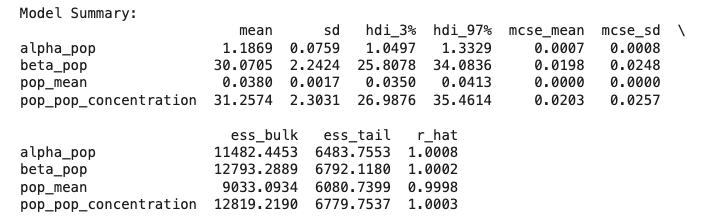

The population mean for AB/HR was 0.0380 (3.8%) with mean total homeruns occuring at 31 HR's.

**2) Add posterior means and a 95% CI for the top 20 players**

In [6]:
posterior = trace.posterior
theta_samples = posterior['theta'].values.reshape(-1, n_players)

posterior_means = theta_samples.mean(axis=0)
posterior_median = np.median(theta_samples, axis=0)
posterior_lower = np.percentile(theta_samples, 2.5, axis=0)
posterior_upper = np.percentile(theta_samples, 97.5, axis=0)
posterior_std = theta_samples.std(axis=0)

results_df = pd.DataFrame({
    'Name': names,
    'AB': ab,
    'HR': hr,
    'Observed_Rate': observed_rates,
    'Posterior_Mean': posterior_means,
    'CI_Lower': posterior_lower,
    'CI_Upper': posterior_upper,
    'CI_Width': posterior_upper - posterior_lower,
    'Posterior_SD': posterior_std,
    'Shrinkage': np.abs(observed_rates - posterior_means),
    'Shrinkage_Pct': np.abs(observed_rates - posterior_means) / (observed_rates + 1e-10) * 100
})

results_df = results_df.sort_values('Posterior_Mean', ascending=False)
results_df['Rank'] = range(1, len(results_df) + 1)

print(f"\n✓ Extracted estimates for {n_players} players")
print(f"  Mean shrinkage: {results_df['Shrinkage'].mean():.4f}")
print(f"  Median shrinkage: {results_df['Shrinkage'].median():.4f}")


✓ Extracted estimates for 445 players
  Mean shrinkage: 0.0017
  Median shrinkage: 0.0011


Create the list for the top 20 players in desending order for observed HR rates

In [7]:
print("\n" + "="*80)
print("TOP 20 PLAYERS BY ESTIMATED HOME RUN RATE (2025 MLB SEASON)")
print("="*80)
print(f"{'Rank':<5} {'Name':<25} {'AB':<6} {'HR':<5} {'Obs Rate':<10} {'Post Mean':<10} {'95% CI':<28}")
print("-"*80)

top_20 = results_df.head(20)

for idx, row in top_20.iterrows():
    ci_str = f"[{row['CI_Lower']:.4f}, {row['CI_Upper']:.4f}]"
    print(f"{row['Rank']:<5} {row['Name']:<25} {row['AB']:<6.0f} {row['HR']:<5.0f} "
          f"{row['Observed_Rate']:<10.4f} {row['Posterior_Mean']:<10.4f} {ci_str:<28}")

print("-"*80)
print(f"Note: Posterior Mean = E[θᵢ | data], 95% CI = Credible Interval")


TOP 20 PLAYERS BY ESTIMATED HOME RUN RATE (2025 MLB SEASON)
Rank  Name                      AB     HR    Obs Rate   Post Mean  95% CI                      
--------------------------------------------------------------------------------
1     Cal Raleigh               639    64    0.1002     0.0973     [0.0758, 0.1205]            
2     Aaron Judge               567    54    0.0952     0.0922     [0.0708, 0.1165]            
3     Kyle Schwarber            620    58    0.0935     0.0908     [0.0701, 0.1145]            
4     Shohei Ohtani             652    60    0.0920     0.0895     [0.0690, 0.1123]            
5     Nick Kurtz                420    36    0.0857     0.0825     [0.0587, 0.1101]            
6     Giancarlo Stanton         275    24    0.0873     0.0823     [0.0546, 0.1158]            
7     Eugenio Suárez            631    52    0.0824     0.0804     [0.0613, 0.1012]            
8     Colson Montgomery         255    21    0.0824     0.0775     [0.0496, 0.1098]       

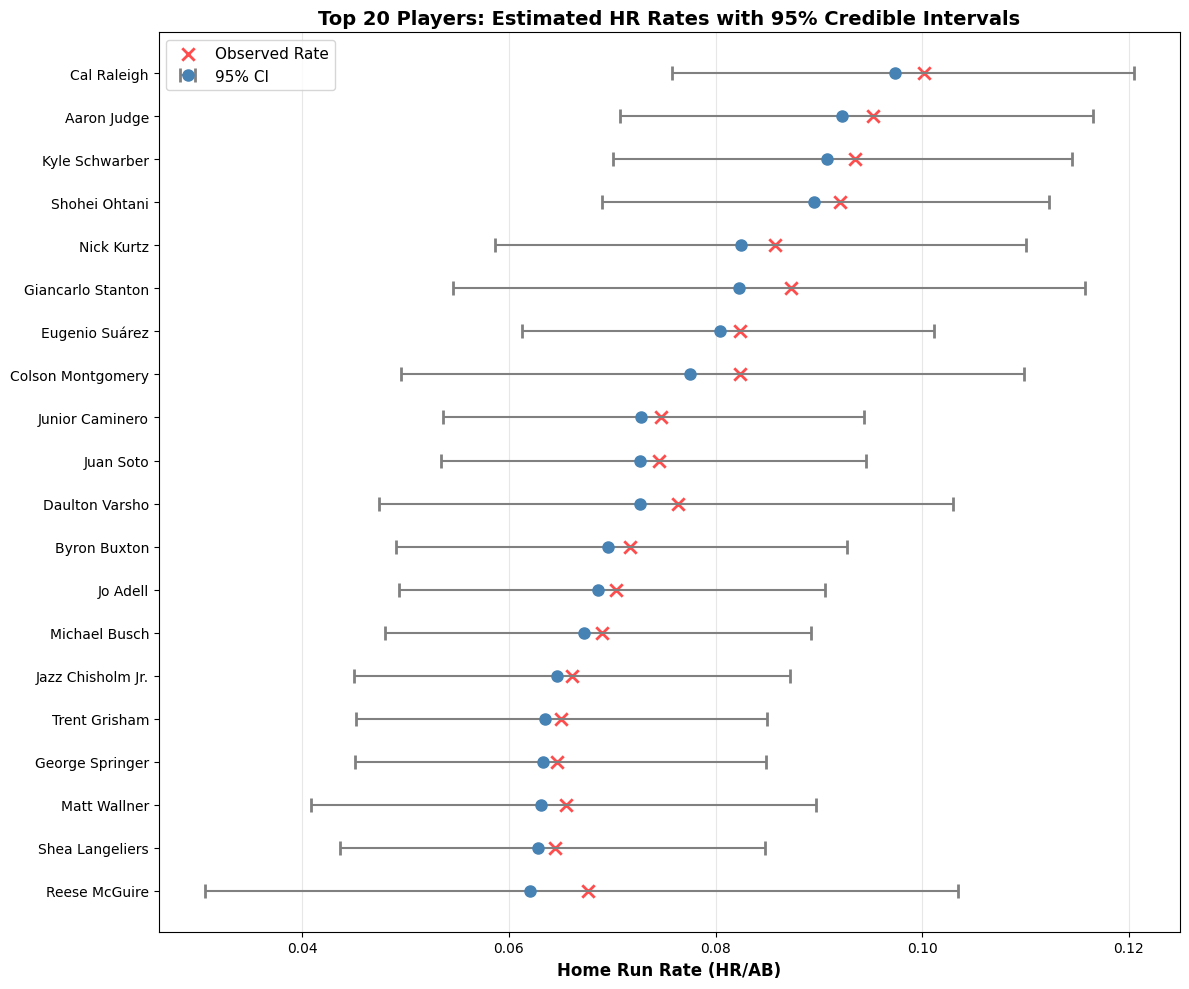

In [8]:
top_20 = results_df.head(20).copy()
top_20 = top_20.iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(top_20))
ax.errorbar(top_20['Posterior_Mean'], y_pos,
            xerr=[top_20['Posterior_Mean'] - top_20['CI_Lower'],
                  top_20['CI_Upper'] - top_20['Posterior_Mean']],
            fmt='o', markersize=8, capsize=5, capthick=2,
            color='steelblue', ecolor='gray', label='95% CI')
ax.scatter(top_20['Observed_Rate'], y_pos, color='red', s=80,
           alpha=0.7, marker='x', linewidths=2, label='Observed Rate')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_20['Name'], fontsize=10)
ax.set_xlabel('Home Run Rate (HR/AB)', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Players: Estimated HR Rates with 95% Credible Intervals',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_20_players_ci.png', dpi=300, bbox_inches='tight')
plt.show()

A graph of the top 20 estimated homerun hitters with confidence intervals shows that all players land within the 95% CI, however as already discussed, the players actual HR's was seen to be higher then expected (likely due to shrinkage).

**3) Produce a Posterior Predictive Check (PPC) figure(s).**

Output()

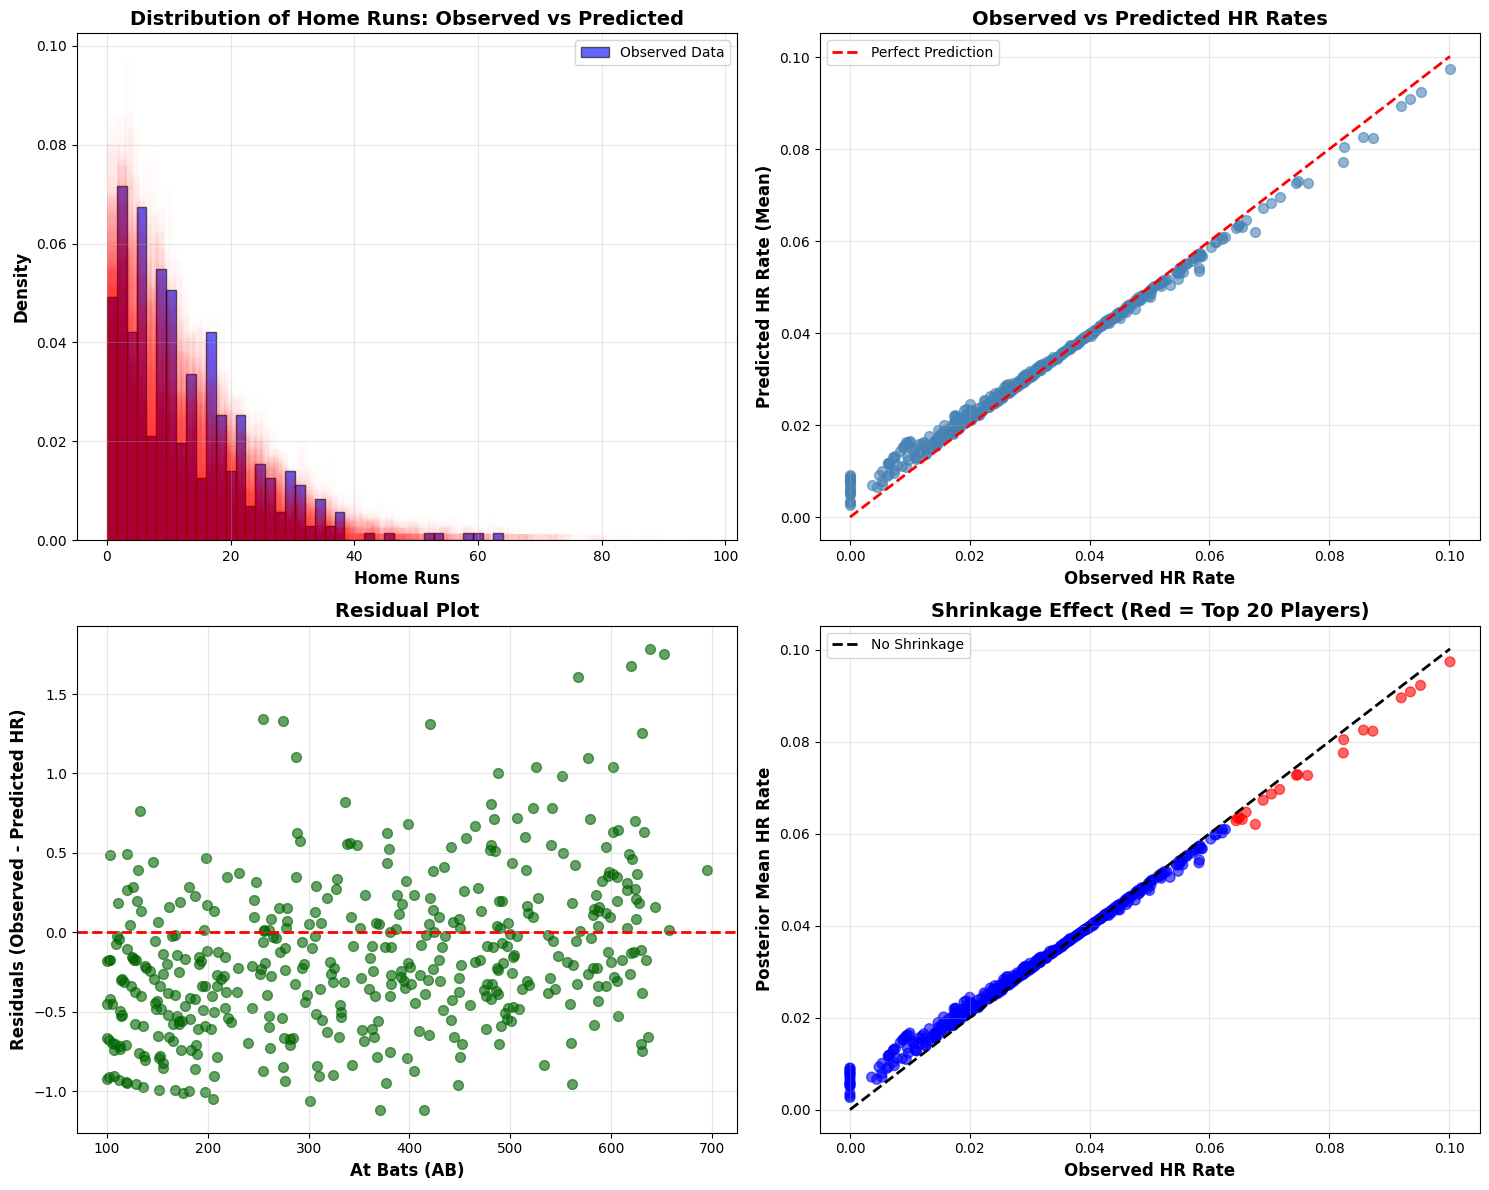

In [9]:
with hierarchical_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)

ppc_samples = ppc.posterior_predictive['hr_obs'].values.reshape(-1, n_players)

# Create PPC figures = standardize size
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Overall distribution
ax1 = axes[0, 0]
ax1.hist(hr, bins=40, alpha=0.6, label='Observed Data', density=True, color='blue', edgecolor='black')
for i in range(min(100, ppc_samples.shape[0])):
    ax1.hist(ppc_samples[i], bins=40, alpha=0.01, density=True, color='red')
ax1.set_xlabel('Home Runs', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Home Runs: Observed vs Predicted', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 2. HR rates comparison
ax2 = axes[0, 1]
predicted_rates = ppc_samples / ab
predicted_mean_rates = predicted_rates.mean(axis=0)
ax2.scatter(observed_rates, predicted_mean_rates, alpha=0.6, s=50, color='steelblue')
max_rate = max(observed_rates.max(), predicted_mean_rates.max())
ax2.plot([0, max_rate], [0, max_rate], 'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Observed HR Rate', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicted HR Rate (Mean)', fontsize=12, fontweight='bold')
ax2.set_title('Observed vs Predicted HR Rates', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# 3. Residual plot
ax3 = axes[1, 0]
residuals = hr - ppc_samples.mean(axis=0)
ax3.scatter(ab, residuals, alpha=0.6, s=50, color='darkgreen')
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('At Bats (AB)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Residuals (Observed - Predicted HR)', fontsize=12, fontweight='bold')
ax3.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)

# 4. Shrinkage visualization
ax4 = axes[1, 1]
top_20_idx = results_df.head(20).index.values
colors = ['red' if i in top_20_idx else 'blue' for i in range(n_players)]
ax4.scatter(observed_rates, posterior_means, alpha=0.6, s=50, c=colors)
max_rate = observed_rates.max()
ax4.plot([0, max_rate], [0, max_rate], 'k--', lw=2, label='No Shrinkage')
ax4.set_xlabel('Observed HR Rate', fontsize=12, fontweight='bold')
ax4.set_ylabel('Posterior Mean HR Rate', fontsize=12, fontweight='bold')
ax4.set_title('Shrinkage Effect (Red = Top 20 Players)', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('posterior_predictive_check.png', dpi=300, bbox_inches='tight')
plt.show()

Looking at these four graphs, a common trend that we see is that the model overpredicts for those in the lower HR rate and underpredicts for those in the higher range. This would make sense though as due to factors of shrinkage, the estimates are pulled towards the group average meaning the lower values would be raised, and the higher values would be shortened.

Graph one depicts a historgram of the observed vs predicted homeruns by the model. This model shows that there is a central tendency of homeruns around the 5-20 mark with fewer hitters having more than 40 Hr's which makes sense based on knowledge of baseball. The model is a good fit if the red overlay is covering the blue histogram which is seen consistently throughout the graph (other than at ~15-18 HR). Moreover, the model also shows a similar shape. However, the model does show density at the lower values as well as the extreme values (> 60 HRs) so it may need to be adjusted to set reasonable end parameters.

**Step 4: 150 Word Discussion**



After analyzing the graphs, the Beta-Binomial Hierachial model shows a relatively accurate depiction of the true affects but clearly demonstrates that shrinkage effects were present.The population mean for HR/AB was 0.038. The shrinkage effects (see extra section below) were most prevalent for players with fewer at bats. P and players with higher at bats would experience less shrinkage as extensive data provides stronger evidence of their actual performance.

Regarding homeruns rates, as discussed previously, the list of the top 20 players with the highest rates were seen to overpredict their estimated values. This is most likely due to the shrinkage factors discussed previously. The model still confidently predicted the values to a 95% CI which is a rather strong depiction due to length of season and number of at bats.

Moreover, The "borrowed" strength from shrinkage prevents us from overreacting to small sample sizes so that if a player has a high HR/AB ratio, their relative value is pooled to a league standard. This is important for understanding player strengths when a player is brought up from the minors and shows high averages due to limited exposures. As the season goes on, players begin to fall back towars the average.

**Extra Section**: shrinkage analysis to understand the values of the discussion

Wanted to see how shrinkage affected players at bats for the discussion above, created a graph of the players with the most shrinkage and the least. What we see is that those with the least generally had >150 AB's.

In [10]:
# Shrinkage Analysis
print("\n" + "="*80)
print("SHRINKAGE ANALYSIS")
print("="*80)

# Calculate shrinkage metrics
results_df['Shrinkage_Pct'] = (np.abs(results_df['Observed_Rate'] -
                                       results_df['Posterior_Mean']) /
                                results_df['Observed_Rate'] * 100)

# Players with most shrinkage
print("\nPlayers with MOST shrinkage (towards population mean):")
high_shrinkage = results_df.nlargest(10, 'Shrinkage')
for i, row in high_shrinkage.iterrows():
    print(f"{row['Name']:<25} AB: {row['AB']:<5.0f} | "
          f"Obs: {row['Observed_Rate']:.4f} → Post: {row['Posterior_Mean']:.4f} | "
          f"Shrinkage: {row['Shrinkage']:.4f}")

print("\nPlayers with LEAST shrinkage (more reliable estimates):")
low_shrinkage = results_df.nsmallest(10, 'Shrinkage')
for i, row in low_shrinkage.iterrows():
    print(f"{row['Name']:<25} AB: {row['AB']:<5.0f} | "
          f"Obs: {row['Observed_Rate']:.4f} → Post: {row['Posterior_Mean']:.4f} | "
          f"Shrinkage: {row['Shrinkage']:.4f}")

# Correlation between AB and shrinkage
correlation = results_df['AB'].corr(results_df['Shrinkage'])
print(f"\nCorrelation between At-Bats and Shrinkage: {correlation:.4f}")


SHRINKAGE ANALYSIS

Players with MOST shrinkage (towards population mean):
Jon Berti                 AB: 100   | Obs: 0.0000 → Post: 0.0091 | Shrinkage: 0.0091
Nick Sogard               AB: 102   | Obs: 0.0000 → Post: 0.0089 | Shrinkage: 0.0089
Tyler Wade                AB: 107   | Obs: 0.0000 → Post: 0.0085 | Shrinkage: 0.0085
Jonah Bride               AB: 112   | Obs: 0.0000 → Post: 0.0083 | Shrinkage: 0.0083
Emmanuel Rivera           AB: 120   | Obs: 0.0000 → Post: 0.0079 | Shrinkage: 0.0079
Jacob Stallings           AB: 119   | Obs: 0.0000 → Post: 0.0079 | Shrinkage: 0.0079
Will Wagner               AB: 129   | Obs: 0.0000 → Post: 0.0074 | Shrinkage: 0.0074
Brandon Lockridge         AB: 136   | Obs: 0.0000 → Post: 0.0071 | Shrinkage: 0.0071
Chas McCormick            AB: 100   | Obs: 0.0100 → Post: 0.0167 | Shrinkage: 0.0067
Justyn-Henry Malloy       AB: 105   | Obs: 0.0095 → Post: 0.0162 | Shrinkage: 0.0067

Players with LEAST shrinkage (more reliable estimates):
Gavin Sheets     